# Neural ODE / Continious Normalizing on MNIST-Dataset

In [57]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchinfo import summary
from torchdiffeq import odeint_adjoint
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
from umap import UMAP


# if nvidia gpu available use it
device = "cuda" if torch.cuda.is_available() else "cpu"

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("Device:", torch.cuda.get_device_name(0))
    print("Compute capability:", torch.cuda.get_device_capability(0))
    print("Supported archs:", torch.cuda.get_arch_list())

PyTorch: 2.11.0+cu130
CUDA available: False


## 1. Loading MNIST-Dataset

In [ ]:
# download test and trainset of mnist via pytorchvision
# define a transformation from PIL to tensor with normalized pixels
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# download mnist dataset
train_set = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

# get images
images = train_set.data
labels = train_set.targets

print()
print(train_set)
print()
print("shape images: ", images.shape)


Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

shape images:  torch.Size([60000, 28, 28])


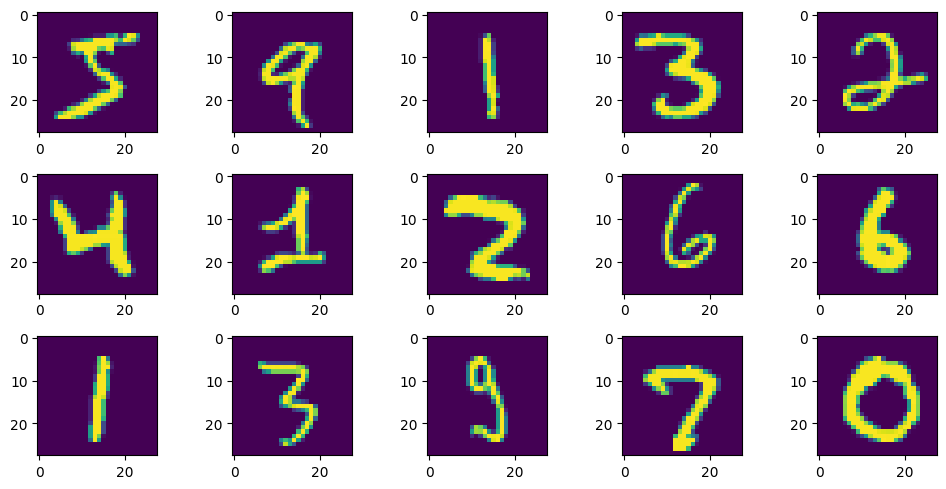

In [59]:
# plot example images
fig, ax = plt.subplots(3, 5, figsize=(10, 5))
ax = ax.flatten()
for i in range(0, 60, 4):
    ax[int(i/4)].imshow(images[i])
fig.tight_layout()

In [101]:
# reduce multidimensional data distribution onto 2D plain with UMAP
reducer = UMAP(n_neighbors=5, n_components=2, min_dist=0.4, metric="euclidean")

# fit reducer onto data
X = images.reshape(len(train_set), -1)
reducer.fit(X)

# make embedding
embedding_train_set = reducer.transform(X).T

(2, 60000)


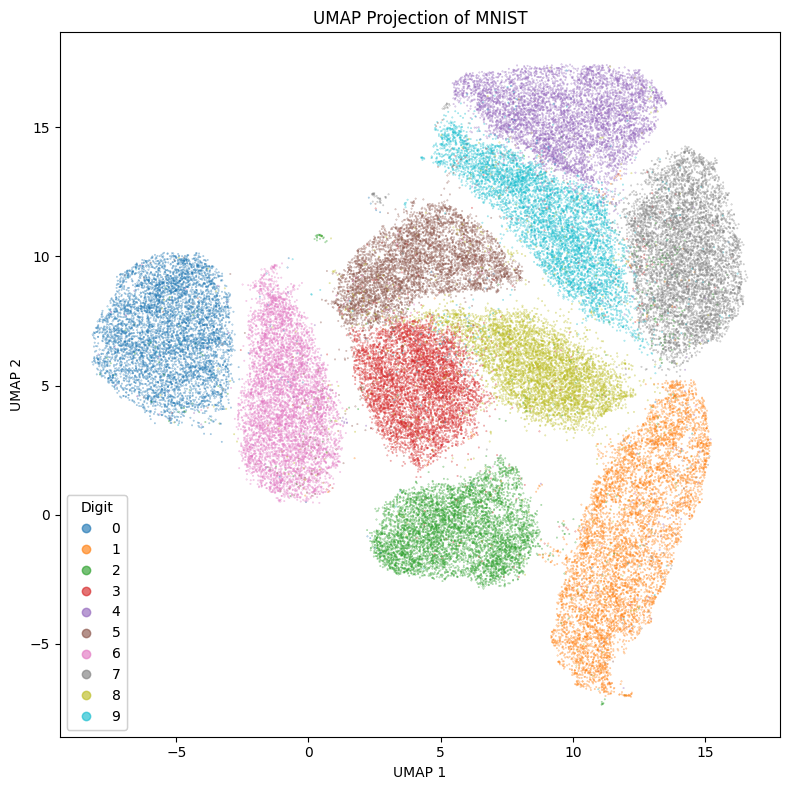

In [102]:
# plot embedding
print(embedding_train_set.shape)

fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(embedding_train_set[0], embedding_train_set[1], s=0.1, alpha=0.6, c=labels, cmap="tab10")
legend = ax.legend(*scatter.legend_elements(), title="Digit", loc="best")
ax.add_artist(legend)

ax.set_title("UMAP Projection of MNIST")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.tight_layout()
plt.show()

## 2. Define Model

In [ ]:
# injection of time t into CNN
def sinusoidal_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(
        -np.log(10000) * torch.arange(half, device=t.device) / half
    )
    args = t[:, None] * freqs[None, :]
    return torch.cat([args.sin(), args.cos()], dim=-1)


class TimeEmbedding(nn.Module):
    def __init__(self, sin_dim=128, t_dim=256):
        super().__init__()
        self.sin_dim = sin_dim
        self.mlp = nn.Sequential(
            nn.Linear(sin_dim, t_dim),
            nn.SiLU(),
            nn.Linear(t_dim, t_dim),
        )

    def forward(self, t):
        h = sinusoidal_embedding(t, self.sin_dim)
        return self.mlp(h)   

In [ ]:
class ResBlock(nn.Module):
    def __init__(self, input_channels, output_channels, t_dim, kernel_size, stride, padding):
        super().__init__()

        # CNN layers
        self.conv1 = nn.Conv2d(in_channels=input_channels, out_channels=output_channels, kernel_size=kernel_size, stride=stride, padding=padding)
        self.norm1 = nn.GroupNorm(8, output_channels)
        self.activation = nn.SiLU()
        self.film = nn.Linear(t_dim, 2*output_channels)
        self.skip  = nn.Conv2d(input_channels, output_channels, 1) if input_channels != output_channels else nn.Identity()

    def forward(self, z, t_emb):
        residual = self.skip(z)
        
        # Conv layer
        z = self.conv1(z)
        z = self.norm1(z)

        # FiLM injection of time
        beta, gamma = self.film(t_emb).chunck(2, -1)
        z = (1+gamma[:, :, None, None]) * z + beta[:, :, None, None]
        
        # activation
        z = self.activation(z)
        return residual + z


class Sampling(nn.Module):
    def __init__(self, kernelsize, channels, upsampling=False):
        super().__init__()
        if not upsampling:
            self.sampling = nn.AvgPool2d(kernel_size=kernelsize)
        else:
            self.sampling = lambda Z: nn.Conv2d(channels, channels, kernel_size=kernelsize, padding=1)(nn.Upsample(kernelsize)(Z))

    def forward(self, z):
        return self.sampling(z)


class CNF():
    def __init__(self):
        pass

    def forward(self, x):
        pass


NameError: name 'nn' is not defined

## 3. Training Model

In [ ]:
# train step function for Neural ODEs
def make_train_step(model, optimizer, regularization, grad_clipping, ode_solver, dim_data, device):
    # define prior
    prior = torch.distributions.MultivariateNormal(torch.zeros(dim_data, device=device), torch.eye(dim_data, device=device))

    # training function that gets created
    def train_step(y_end, t_0, t_end, verbose=False):
        optimizer.zero_grad()
        model.train()

        # calculate ODE Backward to use MLE on Gauss distr with connection to datapoints
        y_0, delta_prob = model(y_end, t_end, t_0, ode_solver)

        # calculate loss (MLE)
        y_0_prob = prior.log_prob(y_0)
        log_p = y_0_prob - delta_prob # - because we calculate integral from 1 to 0 of -trace which is equal to integral from 0 to 1 of trace
        loss_mle = -log_p.mean()

        # Add FFJORD Refularization to make CNF converge (without it diverges to -inf)
        loss_reg = regularization * (delta_prob ** 2).mean()
        loss = loss_mle + loss_reg

        if verbose:
            print(f"prior term: {y_0_prob.mean().item():.3f}")
            print(f"delta_prob: {delta_prob.mean().item():.3f}")

        # calculate gradient
        loss.backward()

        # gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clipping)

        # optimization and scheduler
        optimizer.step()

        return loss.item()
    
    return train_step

In [ ]:
# Circle Training
# training parameters
epochs = 200
lr = 1e-3
t_start = 0
t_end = 1
batch_size = 256
regularization = 0
gradient_clip = 30

# model param
input_dim = 2
dense_dim = 128
resolution = 150

# init model
model = CNF(resolution, input_dim, dense_dim).to(device)
#print(model.state_dict())

# define ODE Solver
solver = "dopri5"
rtol = 1e-5

# define an optimizer
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

# define lr scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

# show model summary
#summary(model, input_size=(batch_size, input_dim))

In [ ]:
# Turn Datasets into Dataloader (Circle)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)

# create training function
training_step_circle = make_train_step(model, optimizer, regularization, gradient_clip, solver, dim_data=input_dim, device=device)

# Training Loop
train_history_circle = []
for e in range(epochs):
    print(f"\nEpoch: {e+1}")

    batch_loss = []
    for i, point_batch in enumerate(train_loader, 1):
        #print(f"Batch: {i}")
        point_batch = point_batch.to(device)

        # information only some epochs
        verbose=False
        if (((e+1)%10==0 or e+1==1)):
            verbose=True
        
        # perform a train step
        loss_b = training_step_circle(point_batch, t_start, t_end, verbose=verbose)
        batch_loss.append(loss_b)
    
    # calculate loss per epoch
    loss_e = np.array(batch_loss).mean()

    # learning rate scheduler
    scheduler.step(loss_e)
    
    # training statistics
    train_history_circle.append(loss_e)
    print(f"Loss: {loss_e}, , Learning Rate: {optimizer.param_groups[0]['lr']}")